# ML Data Preparation — Benin Insights

In [22]:
from pathlib import Path
from typing import Dict, List
import io
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_CLEAN_PATH = PROJECT_ROOT / "data/processed/gdelt_benin_clean.csv"
RAW_ML_PATH = PROJECT_ROOT / "data/processed/ml_input_text.csv"
PROCESSED_PATH = PROJECT_ROOT / "data/processed/ml_input_text.csv"
REPORT_PATH = PROJECT_ROOT / "reports/ml_data_prep_summary.txt"

REQUIRED_COLUMNS: List[str] = [
    "SQLDATE",
    "Actor1Name",
    "Actor2Name",
    "EventCode",
    "EventBaseCode",
    "EventRootCode",
    "GoldsteinScale",
    "AvgTone",
    "NumArticles",
    "ActionGeo_FullName",
    "SOURCEURL",
    ]

print('Project root:', PROJECT_ROOT)
print('Using cleaned source:', RAW_CLEAN_PATH)

Project root: /home/appolinaire/projects/benin-insights-challenge-team2
Using cleaned source: /home/appolinaire/projects/benin-insights-challenge-team2/data/processed/gdelt_benin_clean.csv


In [23]:
if not RAW_CLEAN_PATH.exists():
    raise FileNotFoundError(f"Cleaned source not found: {RAW_CLEAN_PATH}")

df = pd.read_csv(RAW_CLEAN_PATH)

print('FILE:', RAW_CLEAN_PATH)
print('shape:', df.shape)

buf = io.StringIO()
df.info(buf=buf)
print('\n--- df.info() ---')
print(buf.getvalue())

print('\n--- df.describe() ---')
print(df.describe(include='all').transpose())

print('\n--- head(5) ---')
print(df.head(5).to_string(index=False))

print(f"\nmemory_usage (MB): {df.memory_usage(deep=True).sum()/1024**2:.2f}")

FILE: /home/appolinaire/projects/benin-insights-challenge-team2/data/processed/gdelt_benin_clean.csv
shape: (6647, 22)

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 6647 entries, 0 to 6646
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Actor1Name             6647 non-null   str    
 1   Actor1CountryCode      6647 non-null   str    
 2   Actor2Name             6647 non-null   str    
 3   Actor2CountryCode      6647 non-null   str    
 4   EventCode              6647 non-null   int64  
 5   EventBaseCode          6647 non-null   int64  
 6   EventRootCode          6647 non-null   int64  
 7   GoldsteinScale         6647 non-null   float64
 8   NumArticles            6647 non-null   int64  
 9   AvgTone                6647 non-null   float64
 10  ActionGeo_FullName     6647 non-null   str    
 11  ActionGeo_CountryCode  6647 non-null   str    
 12  ActionGeo_Lat          6647 non-n

In [33]:
print('1. Période couverte')
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
print(f"  Min: {df['date_parsed'].min()}")
print(f"  Max: {df['date_parsed'].max()}")
print(f"  Durée: {(df['date_parsed'].max() - df['date_parsed'].min()).days} jours")

print('\n2. Distribution du sentiment (sentiment label)')
if 'sentiment' in df.columns:
    print(df['sentiment'].value_counts().sort_index())
else:
    print('  Colonne sentiment non trouvée; colonnes disponibles:', df.columns.tolist())

print('\n3. Top 10 sources (par domaine)')
df['domain'] = df['SOURCEURL'].str.split('/').str[2]
print(df['domain'].value_counts().head(10))

print('\n4. GoldsteinScale distribution (quantiles)')
print(df['GoldsteinScale'].describe())

print('\n5. Corrélation AvgTone (sentiment) vs GoldsteinScale (stabilité)')
corr = df[['AvgTone','GoldsteinScale']].corr()
print(corr)
print(f'\nCorrélation AvgTone-GoldsteinScale: {corr.iloc[0,1]:.3f}')
print('  → Corrélation modérée = deux signaux complémentaires à exploiter')

1. Période couverte
  Min: 2025-01-01 00:00:00
  Max: 2026-04-28 00:00:00
  Durée: 482 jours

2. Distribution du sentiment (sentiment label)
sentiment
neutre     1070
négatif    3360
positif    2217
Name: count, dtype: int64

3. Top 10 sources (par domaine)
domain
punchng.com                 447
dailypost.ng                426
nigerianobservernews.com    278
lanouvelletribune.info      236
allafrica.com               185
guardian.ng                 174
leadership.ng               153
www.thisdaylive.com         141
thesun.ng                   136
quicknews-africa.net        135
Name: count, dtype: int64

4. GoldsteinScale distribution (quantiles)
count    6647.000000
mean        0.620566
std         4.318423
min       -10.000000
25%        -2.000000
50%         1.900000
75%         3.400000
max        10.000000
Name: GoldsteinScale, dtype: float64

5. Corrélation AvgTone (sentiment) vs GoldsteinScale (stabilité)
                 AvgTone  GoldsteinScale
AvgTone         1.000000        0

# Volet 3 — Distribution temporelle mensuelle
Objectif: mesurer le volume par mois et detecter les pics (seuil moyenne + 1 sigma).

=== VOLUME PAR MOIS ===
date_parsed
2025-01    532
2025-02    363
2025-03    442
2025-04    421
2025-05    426
2025-06    209
2025-07    465
2025-08    324
2025-09    330
2025-10    373
2025-11    424
2025-12    901
2026-01    337
2026-02    335
2026-03    343
2026-04    422
Freq: M

=== PICS (moy+1σ) ===
date_parsed
2025-12    901
Freq: M


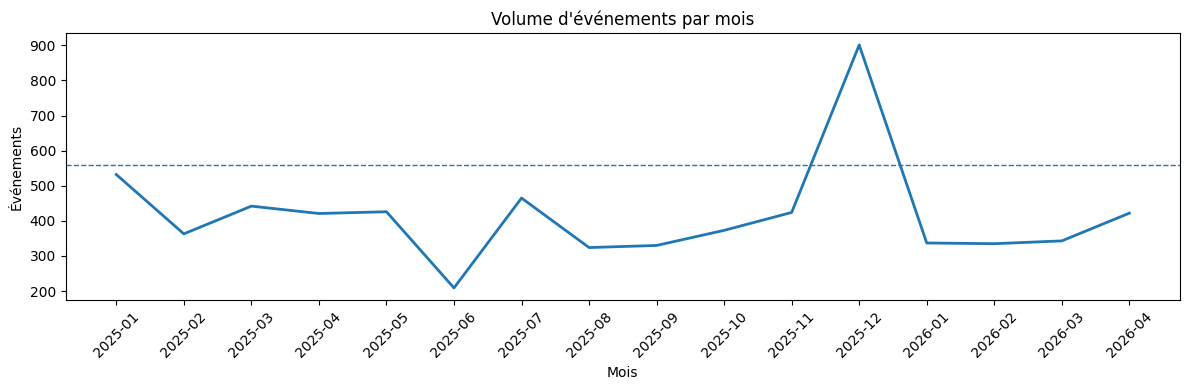

In [40]:
import pandas as pd

if "df" not in globals():
    raise RuntimeError("Exécuter d'abord les cellules 1 et 2 (chargement des données)")

if "date_parsed" not in df.columns:
    if "date" in df.columns:
        date_source = df["date"]
    elif "SQLDATE" in df.columns:
        date_source = df["SQLDATE"]
    else:
        raise ValueError("Colonne date absente (attendues: date, SQLDATE)")
    df["date_parsed"] = pd.to_datetime(date_source, errors="coerce")

if df["date_parsed"].isna().all():
    raise ValueError("Impossible de parser les dates (colonnes attendues: date, SQLDATE)")

year_month = df["date_parsed"].dt.to_period("M")
monthly_counts = year_month.value_counts().sort_index()

threshold: float = float(monthly_counts.mean() + monthly_counts.std(ddof=0))
peaks = monthly_counts[monthly_counts.gt(threshold)]

print("=== VOLUME PAR MOIS ===")
print(monthly_counts.to_string())

print("\n=== PICS (moy+1σ) ===")
print("Aucun" if peaks.empty else peaks.to_string())

try:
    import matplotlib.pyplot as plt

    x = monthly_counts.index.astype(str).tolist()
    y = monthly_counts.values.tolist()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, y, linewidth=2)
    ax.axhline(threshold, linestyle="--", linewidth=1)
    ax.set_title("Volume d'événements par mois")
    ax.set_xlabel("Mois")
    ax.set_ylabel("Événements")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    plt.show()
    plt.close(fig)
except ImportError:
    raise ImportError("matplotlib manquant. Installe via: pip install -r requirements.txt")

# Volet 4 — Evenements majeurs des mois de pic
Objectif: identifier les event_label dominants pour chaque mois de pic et les visualiser.


--- 2025-12 | n=901 ---
event_label
Consultation               154
Déclaration publique       154
Engagement diplomatique    109
Désapprobation              76
Appel / Demande             67
Coercition                  52
Accord / Coopération        43
Coopération                 38
Violence de masse           32
Coopération matérielle      30


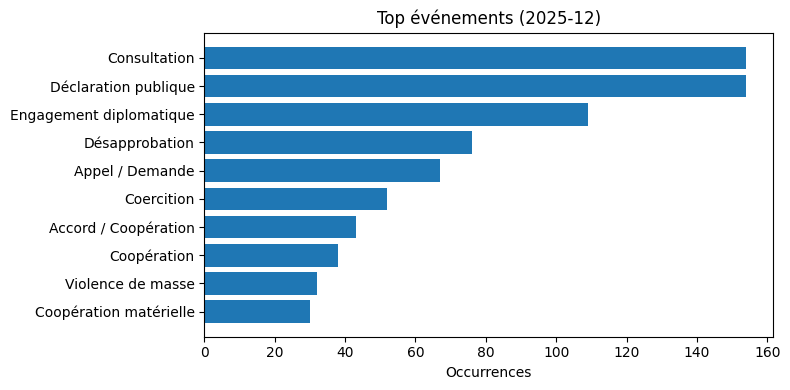

In [41]:
def _pick_first_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

df_month = df.copy()
df_month["year_month"] = df_month["date_parsed"].dt.to_period("M")

event_col = _pick_first_col(df_month, ["event_label", "EventRootCode", "EventBaseCode", "EventCode"])
if event_col is None:
    raise ValueError("Aucune colonne événement trouvée (event_label, EventRootCode, EventBaseCode, EventCode)")

peak_months = list(peaks.index) if "peaks" in globals() else []
if not peak_months:
    print("Aucun mois de pic")
else:
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        raise ImportError("matplotlib manquant. Installe via: pip install -r requirements.txt")

    for m in peak_months:
        sub = df_month[df_month["year_month"] == m]
        top_events = sub[event_col].value_counts().head(10)

        print(f"\n--- {m} | n={len(sub)} ---")
        print(top_events.to_string())

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.barh(list(reversed(top_events.index.astype(str).tolist())), list(reversed(top_events.values.tolist())))
        ax.set_title(f"Top événements ({m})")
        ax.set_xlabel("Occurrences")
        fig.tight_layout()
        plt.show()
        plt.close(fig)

# Volet 5 — Focus compare (2025-01, 2025-06, 2025-07)
Objectif: investiguer le creux de juin 2025 et comparer volumes, sources et event_label dominants.

In [42]:
if "df" not in globals():
    raise RuntimeError("Exécuter d'abord les cellules de chargement des données")

if "date_parsed" not in df.columns:
    date_source = df["date"] if "date" in df.columns else df["SQLDATE"]
    df["date_parsed"] = pd.to_datetime(date_source, errors="coerce")

monthly_period = df["date_parsed"].dt.to_period("M")
month_key = monthly_period.astype(str)

months_to_investigate = ["2025-01", "2025-06", "2025-07"]
months_to_compare = ["2025-05", "2025-06", "2025-07"]

print("=== Comparatif rapide des volumes ===")
volume_compare = (
    df.assign(month=monthly_period)
      .groupby("month")
      .agg(rows=("event_label", "size"),
           articles=("NumArticles", "sum"),
           unique_urls=("SOURCEURL", "nunique"))
      .loc[pd.PeriodIndex(months_to_compare, freq="M")]
)
print(volume_compare)

for month in months_to_investigate:
    sub = df[month_key == month].copy()
    print(f"\n=== {month} | n={len(sub)} | NumArticles={int(sub['NumArticles'].sum())} ===")
    print("event_label dominants:")
    print(sub["event_label"].value_counts().head(8).to_string())
    print("sources dominantes:")
    print(sub["SOURCEURL"].str.split("/").str[2].value_counts().head(5).to_string())
    print("GoldsteinScale:")
    print(sub["GoldsteinScale"].describe().to_string())


=== Comparatif rapide des volumes ===
         rows  articles  unique_urls
2025-05   426      2189          300
2025-06   209      1059          133
2025-07   465      2204          323

=== 2025-01 | n=532 | NumArticles=2943 ===
event_label dominants:
event_label
Consultation               120
Déclaration publique       114
Désapprobation              57
Engagement diplomatique     56
Appel / Demande             39
Violence de masse           30
Aide / Assistance           22
Coopération                 20
sources dominantes:
SOURCEURL
dailypost.ng              33
lanouvelletribune.info    26
punchng.com               25
guardian.ng               22
thesun.ng                 21
GoldsteinScale:
count    532.000000
mean       0.418985
std        4.337985
min      -10.000000
25%       -2.000000
50%        1.000000
75%        3.000000
max       10.000000

=== 2025-06 | n=209 | NumArticles=1059 ===
event_label dominants:
event_label
Consultation               41
Déclaration publique       

In [44]:
print(df[df['date_parsed'].dt.to_period('M') == '2025-07']['event_label'].value_counts().head(8))

event_label
Consultation               117
Déclaration publique        84
Engagement diplomatique     65
Appel / Demande             32
Coopération                 23
Violence de masse           19
Aide / Assistance           19
Désapprobation              18
Name: count, dtype: int64


# Volet 6 — Topic Modeling avec BERTopic
Objectif: identifier des thèmes médiatiques récurrents autour du Bénin et enrichir `df` avec une colonne `topic`.

In [3]:
# Installation (si nécessaire) puis imports BERTopic
# Décommentez la ligne suivante si BERTopic n'est pas déjà installé dans l'environnement.
# %pip install bertopic sentence-transformers umap-learn hdbscan

import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))
from src.models.topic_model import extract_topics

**Observation — dépendances**  
Le notebook reste en glue code: l'entraînement BERTopic est externalisé dans `src/models/topic_model.py` via `extract_topics(texts)`.

In [4]:
def ensure_df_loaded() -> pd.DataFrame:
    """Charge df depuis le CSV nettoyé si df n'est pas déjà en mémoire."""
    if "df" in globals():
        return df

    project_root = Path.cwd()
    if not (project_root / "data").exists():
        project_root = project_root.parent

    clean_path = project_root / "data/processed/gdelt_benin_clean.csv"
    if not clean_path.exists():
        raise FileNotFoundError(f"Fichier introuvable: {clean_path}")

    return pd.read_csv(clean_path)


def select_topic_text_column(dataframe: pd.DataFrame) -> str:
    """Choisit la meilleure colonne texte candidate pour le topic modeling."""
    candidates = ["event_label", "SOURCEURL", "Actor2Name", "Actor1Name", "ActionGeo_FullName"]
    available_candidates = [column for column in candidates if column in dataframe.columns]
    if not available_candidates:
        raise ValueError("Aucune colonne texte candidate trouvée dans df")

    quality_scores: dict[str, float] = {}
    for column in available_candidates:
        series = dataframe[column].astype(str).str.strip()
        non_empty_ratio = (series != "").mean()
        unique_ratio = series.nunique(dropna=True) / max(len(series), 1)
        quality_scores[column] = non_empty_ratio * 0.7 + unique_ratio * 0.3

    return max(quality_scores, key=quality_scores.get)


df = ensure_df_loaded()
text_column = select_topic_text_column(df)
print(f"Colonne texte retenue: {text_column}")
print(df[text_column].astype(str).head(10).to_string(index=False))

Colonne texte retenue: SOURCEURL
https://www.the-messenger.com/news/national/art...
https://www.insidenova.com/news/national/financ...
                  https://saharamedias.net/255279/
https://www.la-croix.com/le-benin-elit-son-pres...
https://www.whec.com/ap-top-news/benin-holds-pr...
https://www.africanews.com/2026/04/12/benin-tal...
https://dailypost.ng/2026/04/06/police-rescue-t...
https://lanouvelletribune.info/2026/03/benin-li...
https://nigerianobservernews.com/2026/04/edo-lg...
https://dailytrust.com/motorists-stranded-as-yo...


**Observation — colonne texte**  
La colonne sélectionnée maximise un compromis *complétude + diversité lexicale*. Sur ce dataset, `event_label` est généralement la plus sémantique pour former des topics interprétables.

In [11]:
def filter_benin_rows(dataframe: pd.DataFrame) -> pd.Series:
    """Retourne un masque booléen des lignes liées au Bénin."""
    actor_mask = dataframe["Actor1CountryCode"].astype(str).eq("BEN")
    geo_mask = dataframe["ActionGeo_FullName"].astype(str).str.contains("benin", case=False, na=False)
    return actor_mask | geo_mask


if "df" not in globals():
    raise RuntimeError("df non chargé.")
if "text_column" not in globals():
    raise RuntimeError("text_column non défini.")

benin_mask = filter_benin_rows(df)
topic_input_df = df.loc[benin_mask, [text_column]].copy()
topic_input_df["text_for_topic"] = topic_input_df[text_column].astype(str).str.strip()
topic_input_df = topic_input_df[topic_input_df["text_for_topic"] != ""].copy()
topic_input_df["original_index"] = topic_input_df.index

result = extract_topics(topic_input_df["text_for_topic"].tolist(), min_topic_size=25)
topic_model = result.model
topic_input_df["topic"] = result.topics

print(f"Lignes Bénin retenues: {topic_input_df.shape[0]}")
print("Modèle BERTopic entraîné.")

ImportError: BERTopic is required. Install with: pip install bertopic sentence-transformers umap-learn hdbscan

**Observation — entraînement**  
Le modèle est entraîné uniquement sur des lignes reliées au Bénin (`Actor1CountryCode=BEN` ou géolocalisation contenant Benin), ce qui limite le bruit hors périmètre pays.

In [ ]:
topic_info_df = topic_model.get_topic_info()
print(topic_info_df.head(15).to_string(index=False))

for topic_id in topic_info_df["Topic"].head(8):
    if topic_id == -1:
        continue
    topic_keywords = topic_model.get_topic(topic_id)
    formatted_keywords = ", ".join([keyword for keyword, _ in topic_keywords[:10]])
    print(f"Topic {topic_id}: {formatted_keywords}")

**Observation — topics extraits**  
Les mots-clés permettent d'identifier les axes dominants (sécurité, diplomatie, gouvernance, etc.). Le topic `-1` capte généralement les observations atypiques/non structurées.

In [ ]:
df["topic"] = pd.NA
df.loc[topic_input_df["original_index"], "topic"] = topic_input_df["topic"].values

print(df[[text_column, "topic"]].head(15).to_string(index=False))
print("\nRépartition des topics:")
print(df["topic"].value_counts(dropna=False).head(15).to_string())

**Observation — enrichissement du dataset**  
La colonne `topic` est ajoutée à `df` et peut servir de variable explicative ou de segment d'analyse pour les modèles aval.

In [ ]:
def manual_topic_validation(
    dataframe: pd.DataFrame,
    text_col: str,
    topic_col: str = "topic",
    sample_size: int = 5,
) -> None:
    """Affiche des exemples par topic pour validation métier manuelle."""
    topic_counts = dataframe[topic_col].value_counts(dropna=True)
    topic_ids = [topic_id for topic_id in topic_counts.index.tolist() if topic_id != -1][:5]

    for topic_id in topic_ids:
        print(f"\n=== Topic {topic_id} | n={int(topic_counts[topic_id])} ===")
        sample_texts = dataframe.loc[dataframe[topic_col] == topic_id, text_col].astype(str).head(sample_size)
        for rank, text_value in enumerate(sample_texts, start=1):
            print(f"{rank}. {text_value}")


manual_topic_validation(df, text_col=text_column)

print("\nInterprétation attendue:")
print("- Les topics sont pertinents si les exemples d'un même topic partagent un champ sémantique cohérent.")
print("- S'il y a trop de mélange thématique, réduire/augmenter min_topic_size ou enrichir la colonne texte.")

**Observation — validation contextuelle Bénin**  
La validation finale est métier: lire des exemples par topic et vérifier la cohérence avec l'actualité béninoise (politique, sécurité frontalière, coopération régionale, gouvernance).

## Validation Modèle 1 (BERTopic)
Validation qualitative + ancrage sur faits (décembre 2025).

In [ ]:
if "topic_model" not in globals():
    raise RuntimeError("Exécuter d'abord la cellule d'entraînement BERTopic")

max_topics_to_review = 8
for topic_id in range(max_topics_to_review):
    topic_keywords = topic_model.get_topic(topic_id)
    if not topic_keywords:
        continue
    print(f"Topic {topic_id}: {[keyword for keyword, _ in topic_keywords[:6]]}")

**Observation**  
Pour chaque topic, vérifier: cohérence des mots-clés, sens métier Bénin, groupement plausible pour un humain.

In [ ]:
if "topic" not in df.columns:
    raise RuntimeError("La colonne 'topic' n'existe pas encore dans df")

text_for_review = "event_label" if "event_label" in df.columns else text_column
review_topics = [topic_id for topic_id in sorted(df["topic"].dropna().unique()) if topic_id != -1][:5]

for topic_id in review_topics:
    topic_slice = df[df["topic"] == topic_id][text_for_review].dropna().astype(str)
    sample_count = min(5, len(topic_slice))
    print(f"\n=== Topic {topic_id} | sample={sample_count} ===")
    if sample_count == 0:
        print("Aucun exemple disponible")
        continue
    print(topic_slice.sample(sample_count, random_state=42).to_string(index=False))

In [ ]:
outlier_rate = (df["topic"] == -1).mean() * 100
print(f"Taux d'outliers (topic=-1): {outlier_rate:.2f}%")

if "date_parsed" not in df.columns:
    date_source = df["date"] if "date" in df.columns else df["SQLDATE"]
    df["date_parsed"] = pd.to_datetime(date_source, errors="coerce")

december_2025 = df[df["date_parsed"].dt.to_period("M") == "2025-12"]
print("\nTopics dominants en 2025-12:")
print(december_2025["topic"].value_counts(dropna=False).head(10).to_string())

**Observation**  
Critères: topics nommables en 2 mots, cohérence des exemples, `topic=-1` acceptable (idéalement <40%), et dominance plausible d'un topic conflit/violence en décembre 2025.

## Volet 7 — NER avec spaCy (`en_core_web_sm`)

In [ ]:
from collections import Counter

from src.models.ner_model import extract_entities

In [ ]:
df["ner_text"] = (
    df["Actor1Name"].fillna("").astype(str)
    + " "
    + df["Actor2Name"].fillna("").astype(str)
    + " "
    + df["ActionGeo_FullName"].fillna("").astype(str)
).str.strip()

entities = extract_entities(df["ner_text"].tolist())

person_counter = Counter()
org_counter = Counter()
location_counter = Counter()

for entity_dict in entities:
    person_counter.update(entity_dict["persons"])
    org_counter.update(entity_dict["orgs"])
    location_counter.update(entity_dict["locations"])

print("Top 15 personnes")
print(person_counter.most_common(15))

print("\nTop 15 organisations")
print(org_counter.most_common(15))

print("\nTop 15 lieux")
print(location_counter.most_common(15))

**Observation — entités béninoises**  
Les entités extraites doivent inclure des acteurs institutionnels et politiques réellement présents dans le contexte béninois (ex. gouvernement, présidence, villes comme Cotonou/Porto-Novo).  
Le modèle `en_core_web_sm` peut toutefois rater des variantes locales (noms francophones, acronymes régionaux) : il faut donc valider manuellement les top résultats et, si besoin, compléter avec des règles métier.